# 29_model_guidebook_lstm_ae_JIW

- 목적: 공식 가이드북(2.3 분석 체험)의 **LSTM-Autoencoder를 재현(G1)**하고, 같은 모델에 **팀 평가 계약을 적용(G2)**해 "누수를 막으면 성능이 어떻게 변하나"와 "우리 9종 모델과 비교해 어떤가"를 본다.
- 입력: `data/raw`(→ `data_quality.load_all`, `preprocess.preprocess()`), `data/processed/11_window_features.parquet`(윈도우·분할), `results/model_comparison.csv`
- 출력: `figures/29_model_guidebook_lstm_ae_JIW/`, `results/29_model_guidebook_lstm_ae_JIW/`(g1_runs.csv · cv_scores.csv · error_cases.csv · scores.csv · metrics.csv · compare_models.csv), `models/29_model_guidebook_lstm_ae_JIW/`(G2 가중치 18개, git 제외)
- 담당: JIW
- 탐지 대상: 유압펌프 모터-펌프 구동부 이상 (센서 부착 부위 미확정)
- 심사 대응: 2번(가이드북 방식 재현과 팀 모델 비교), 1번(누수 가능성: 가이드북 방식의 평가 설계 점검)
- 근거 표기: **[데이터]** 이 노트북 출력 / **[추정]** 미검증

## 가이드북 방식(G1)과 팀 계약 적용(G2)

| 항목 | G1 (가이드북 원본) | G2 (팀 계약 적용) |
|---|---|---|
| 입력 | 원시 3채널에 `abs()` → MinMax(학습 정상으로 fit) | `preprocess.preprocess()`(형식 통일 + 세그먼트 평균 제거), abs 안 씀, 채널별 MinMax(train 정상 세그먼트로 fit) |
| 시퀀스 | 행을 이어 붙여 과거 20개(2초), 정답 = index+20+100(10초 뒤), burst 공백을 넘음 | **세그먼트 안에서만** 20개, 점수는 평가 윈도우(1·2초) 안 시점별 재구성 오차의 평균 |
| 분할 | 정상 앞 15,000행 학습 / 뒤 5,000행 + 이상 전체 평가 | `group_kfold_seg` 5 + `time_block` 4 (세그먼트 단위) |
| 임계 | 검증 세트(평가 정상 880 + **이상 300**)에서 정밀도 = 재현율인 점수 → **이상 데이터를 임계에 씀** | train 정상 점수의 q99, 이상 데이터 미사용 |
| 모델 | LSTM(64) → LSTM(32) → RepeatVector → LSTM(32) → LSTM(64) → Dense(3), 파라미터 63,939개 | 같음 |
| 학습 | Adam 1e-3, MSE, 배치 128, 최대 800 epoch, EarlyStopping(120), ReduceLROnPlateau(0.7, 50) | Adam 1e-3, MSE, 배치 128, **최대 100 epoch**, EarlyStopping(20), ReduceLROnPlateau(0.7, 10) — 분할 18회라 원 설정으로는 하루 이상 걸려 **축소** |

> 모델 구조는 두 버전이 같고, 바뀌는 것은 입력 처리·시퀀스·분할·임계·학습 길이다. G2의 학습 길이 축소가 성능 저하에 얼마나 기여하는지는 **분리하지 않았다**(§4).

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import paths
NB = "29_model_guidebook_lstm_ae_JIW"  # 파일명(확장자 제외)과 같게
FIG, RES = paths.nb_dirs(NB)
SEED = 42
np.random.seed(SEED)
import benchmark_jiw as B
import evaluate as ev
import guidebook_g1 as G1
import guidebook_g2 as G2
import torch
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
RETRAIN = False        # G2 가중치(models/29_model_guidebook_lstm_ae_JIW/)가 있으면 불러온다. G1은 CPU 약 85분이라 results/g1_runs.csv를 읽는다
print(NB, FIG.relative_to(ROOT), RES.relative_to(ROOT))

29_model_guidebook_lstm_ae_JIW figures\29_model_guidebook_lstm_ae_JIW results\29_model_guidebook_lstm_ae_JIW


## 1. G1: 가이드북 원본 방식 재현

가이드북 38~39쪽 보고 결과와, PyTorch로 다시 구현해 학습한 결과(시드 0, 800 epoch 전부 수행)를 비교한다. 같은 데이터 분할(학습 15,000행, 검증 880+300 시퀀스, 평가 4,000 정상 + 180 이상 시퀀스)이다.

In [2]:
g1 = pd.read_csv(RES / "g1_runs.csv")     # python src/guidebook_g1.py <seed> 로 만들거나 갱신한다(CPU 약 85분/시드)
rep = G1.GUIDEBOOK_REPORTED
tn, fp, fn, tp = rep["TN"], rep["FP"], rep["FN"], rep["TP"]
gb = {"방식": "가이드북 보고치(Keras)", "TN": tn, "FP": fp, "FN": fn, "TP": tp, "정확도": (tn + tp) / (tn + fp + fn + tp), "정밀도": tp / (tp + fp),
      "재현율": tp / (tp + fn), "F1": 2 * tp / (2 * tp + fp + fn), "오경보율": fp / (fp + tn), "AUC": np.nan}
mine = g1.iloc[0]
mn = {"방식": f"재현(PyTorch, 시드 {int(mine.seed)}, {int(mine.epochs_run)} epoch)", "TN": mine.TN, "FP": mine.FP, "FN": mine.FN, "TP": mine.TP, "정확도": mine.accuracy,
      "정밀도": mine.precision, "재현율": mine.recall, "F1": mine.f1, "오경보율": mine.fpr, "AUC": mine.auc}
cmp1 = pd.DataFrame([gb, mn]).set_index("방식")
cmp1.round(3)

,TN,FP,FN,TP,정확도,정밀도,재현율,F1,오경보율,AUC
방식,,,,,,,,,,
가이드북 보고치(Keras),3922.0,78.0,26.0,154.0,0.975,0.664,0.856,0.748,0.020,NaN
"재현(PyTorch, 시드 0, 800 epoch)",3889.0,111.0,45.0,135.0,0.963,0.549,0.750,0.634,0.028,0.957


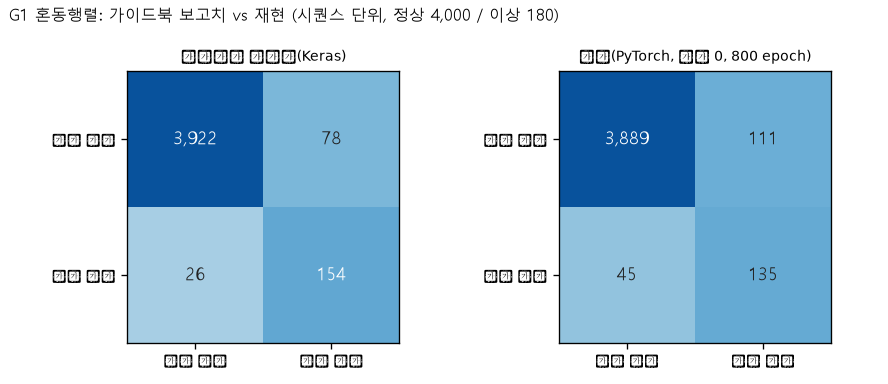

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.2))
B._style()
for ax, (nm, r) in zip(axes, cmp1.iterrows()):
    m = np.array([[r["TN"], r["FP"]], [r["FN"], r["TP"]]])
    ax.imshow(np.log1p(m), cmap="Blues", vmin=0, vmax=np.log1p(m.max()) * 1.15)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{int(m[i, j]):,}", ha="center", va="center", fontsize=11, color="white" if np.log1p(m[i, j]) > np.log1p(m.max()) * 0.6 else "#222")
    ax.set_xticks([0, 1], ["정상 판정", "이상 판정"], fontsize=8); ax.set_yticks([0, 1], ["실제 정상", "실제 이상"], fontsize=8)
    ax.set_title(nm.replace(" (", "\n("), fontsize=8.5); ax.grid(False)
fig.suptitle("G1 혼동행렬: 가이드북 보고치 vs 재현 (시퀀스 단위, 정상 4,000 / 이상 180)", x=0.01, ha="left", fontsize=9.5)
fig.tight_layout(); fig.savefig(FIG / "g1_confusion.png", dpi=120); plt.close(fig)
display(Image(FIG / "g1_confusion.png"))

**발견 [데이터]**
- 재현한 G1은 가이드북보다 **약간 나쁘다**: 오경보 111건(가이드북 78), 미탐 45건(26), 재현율 0.750(0.856), F1 0.634(0.748). AUC는 0.957이다.
- 검증 세트의 정밀도 = 재현율이 0.75로 맞춰졌고(임계 0.0217), 평가에서도 재현율이 0.750으로 같다. 임계를 **이상 300개로 정했기** 때문에 평가의 이상 시퀀스에서도 비슷하게 나온다.
- 차이의 원인(Keras vs PyTorch 초기화·옵티마이저 세부, 시드 1개, 정밀도 = 재현율 지점 선택의 민감도)은 **분리하지 않았다**. 시드를 늘리면 줄어들 수 있다 [추정]. 이 재현의 목적은 가이드북 수치를 정확히 맞추는 것이 아니라 "비슷한 수준(오경보 2%대, 재현율 0.75~0.86)이 나온다"는 확인이다.

### G1의 평가 설계에서 점검할 점 (심사 1번 관련)

| 점검 | 내용 |
|---|---|
| 이상으로 임계 결정 | 검증 세트에 이상 300개가 들어가 정밀도 = 재현율 지점을 고른다 → 임계가 이상에 맞춰짐 |
| 날짜 = 라벨 | 평가 정상은 7/12, 이상은 7/17. 모델이 날짜(설비 상태·측정 조건) 차이를 학습해도 구분되지 않는다 |
| 파일 형식 누수 | 입력이 원시값의 `abs()`라 DC 오프셋·수치 형식 차이가 그대로 남는다(팀 03: 형식 피처 AUC 1.000) |
| 시퀀스 | burst 공백을 넘어 행을 이어 붙이고 평가 시퀀스는 학습과 같은 날짜의 뒷 5,000행 |
| 평가 단위 | 시퀀스 단위 혼동행렬이라 이상 180개는 서로 겹친 시퀀스(실제 독립 표본은 이벤트 1건) |

그래서 G1의 "정확도 96~97%"를 다른 모델의 성능과 직접 비교하면 안 된다. 같은 모델을 팀 계약으로 평가한 것이 G2다.

## 2. G2: 같은 모델에 팀 계약을 적용

입력 전처리·세그먼트 안 시퀀스·세그먼트 단위 분할·train 정상 q99 임계를 적용했다. 저장된 가중치(18개, 시드 0)를 불러와 같은 평가를 한다.

In [4]:
cv, err, sc = G2.run_g2(NB, win_list=(1.0, 2.0), seeds=(0,), retrain=RETRAIN, progress=False)
metrics = B.to_metrics(cv.assign(model_id=cv["model_id"]))
metrics.to_csv(RES / "metrics.csv", index=False)
cv.to_csv(RES / "cv_scores.csv", index=False)
err.to_csv(RES / "error_cases.csv", index=False)
sc.to_csv(RES / "scores.csv", index=False)
print(cv["status"].value_counts().to_dict(), "runs", len(cv))
cols = ["auc", "fpr_sample", "fpr_segment", "recall_window", "n_detected", "n_out_seg", "fpr_high_load", "fpr_low_load", "epochs_run", "felt_delay_median_s"]
cv.groupby(["win_s", "split"])[cols].mean().round(3)

{'loaded': 18} runs 18


auc  fpr_sample  fpr_segment  recall_window  n_detected  n_out_seg  fpr_high_load  fpr_low_load  epochs_run  felt_delay_median_s
win_s split                                                                                                                                              
1.0   group_kfold_seg  0.863       0.006        0.013          0.605        2.20        3.4          0.010         0.003       99.40                9.158
      time_block       0.741       0.012        0.024          0.346        8.75       17.0          0.024         0.000       60.25               10.296
2.0   group_kfold_seg  0.922       0.008        0.035          0.738        2.40        2.6          0.016         0.001      100.00               10.408
      time_block       0.821       0.013        0.063          0.552       10.25       13.0          0.028         0.000       73.50                9.983

In [5]:
cv[["win_s", "split", "fold", "epochs_run", "auc", "fpr_segment", "n_detected", "n_out_seg"]].round(3)

,win_s,split,fold,epochs_run,auc,fpr_segment,n_detected,n_out_seg
0,1.0,group_kfold_seg,0,97,0.841,0.028,3,5
1,1.0,group_kfold_seg,1,100,0.792,0.010,2,4
2,1.0,group_kfold_seg,2,100,1.000,0.000,2,2
3,1.0,group_kfold_seg,3,100,0.937,0.018,3,3
4,1.0,group_kfold_seg,4,100,0.747,0.010,1,3
5,1.0,time_block,1,34,0.630,0.029,8,17
6,1.0,time_block,2,62,0.746,0.020,9,17
7,1.0,time_block,3,100,0.737,0.046,9,17
8,1.0,time_block,4,45,0.852,0.000,9,17
9,2.0,group_kfold_seg,0,100,0.967,0.080,3,3


**발견 [데이터]**
- G2의 AUC는 2초 group_kfold 0.922, time_block 0.821(1초는 0.863 / 0.741)로 **G1의 0.957보다 낮다.** 누수(형식·날짜)가 사라지고 팀 계약으로 평가하면 같은 모델의 성능이 내려간다 — G1의 높은 수치에 형식·날짜 효과가 섞여 있었다는 방향의 증거다 [추정]. 단 G1은 시퀀스 단위·고정 분할, G2는 윈도우 단위·세그먼트 분할이라 숫자를 직접 빼서 비교하기는 거칠고, 학습 길이 축소 효과와도 분리하지 못했다.
- 실제 이상 세그먼트를 놓친다: 2초 time_block에서 13개 중 9·11·9·12개만 탐지, 1초는 17개 중 8~9개(group_kfold 11/17). 우리 CNN·LSTM-AD·MTAD-GAT·MCD는 13/13이다.
- 학습 epoch이 상한(100)에 닿은 fold가 많고(2초 group_kfold는 5개 모두, 1초는 5개 중 4개 100·1개 97, time_block은 33~100에서 조기 종료) **수렴하지 않았을 가능성**이 있다. time_block 1~2는 학습 정상이 98~183 세그먼트뿐이다.

## 3. 우리 모델과 비교 (2초 윈도우)

In [6]:
mc = pd.read_csv(paths.RESULTS / "model_comparison.csv")
pick = {"rule3_rms_state_dir": "규칙 3 (상태별 크기 × 방향)", "cnn_deepant_w2s": "CNN (DeepAnT 변형)", "lstm_ad_w2s": "LSTM-AD", "mtad_gat_w2s": "MTAD-GAT",
        "mcd_amp_w2s": "MCD [amp]", "pca_raw_ae_all3_w2s": "PCA 오토인코더", "cnn_lstm_ae_all3_w2s": "CNN+LSTM 오토인코더 (팀 27)"}
mc = mc[mc["model"].isin(pick) & (mc["win_s"] == 2.0)].copy()
mc["모델"] = mc["model"].map(pick)
g2 = cv[cv["win_s"] == 2.0].groupby("split")[["auc", "fpr_sample", "fpr_segment", "n_detected", "n_out_seg"]].mean().reset_index()
g2["모델"] = "가이드북 LSTM-AE (G2, 팀 계약)"
cmp2 = pd.concat([mc[["모델", "split", "auc", "fpr_sample", "fpr_segment", "n_detected", "n_out_seg"]], g2[["모델", "split", "auc", "fpr_sample", "fpr_segment", "n_detected", "n_out_seg"]]])
cmp2 = cmp2.pivot_table(index="모델", columns="split", values=["auc", "fpr_segment", "n_detected", "n_out_seg"]).round(3)
cmp2.to_csv(RES / "compare_models.csv")
cmp2

auc                fpr_segment                 n_detected                  n_out_seg           
split                   group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block group_kfold_seg time_block
모델                                                                                                                                 
CNN (DeepAnT 변형)                  1.000      1.000           0.028      0.018             2.6      13.00             2.6       13.0
CNN+LSTM 오토인코더 (팀 27)             0.996      0.994           0.064      0.093             2.6      12.75             2.6       13.0
LSTM-AD                           1.000      1.000           0.026      0.017             2.6      13.00             2.6       13.0
MCD [amp]                         1.000      1.000           0.038      0.031             2.6      13.00             2.6       13.0
MTAD-GAT                          1.000      1.000           0.022      0.025             2.6      13.00             2.6       13.0
PCA 오토인코더                         1.000      1.000           0.040      0.046             2.6      13.00             2.6       13.0
가이드북 LSTM-AE (G2, 팀 계약)           0.922      0.821           0.035      0.063             2.4      10.25             2.6       13.0
규칙 3 (상태별 크기 × 방향)                0.910      0.920           0.023      0.008             2.4      12.00             2.6       13.0

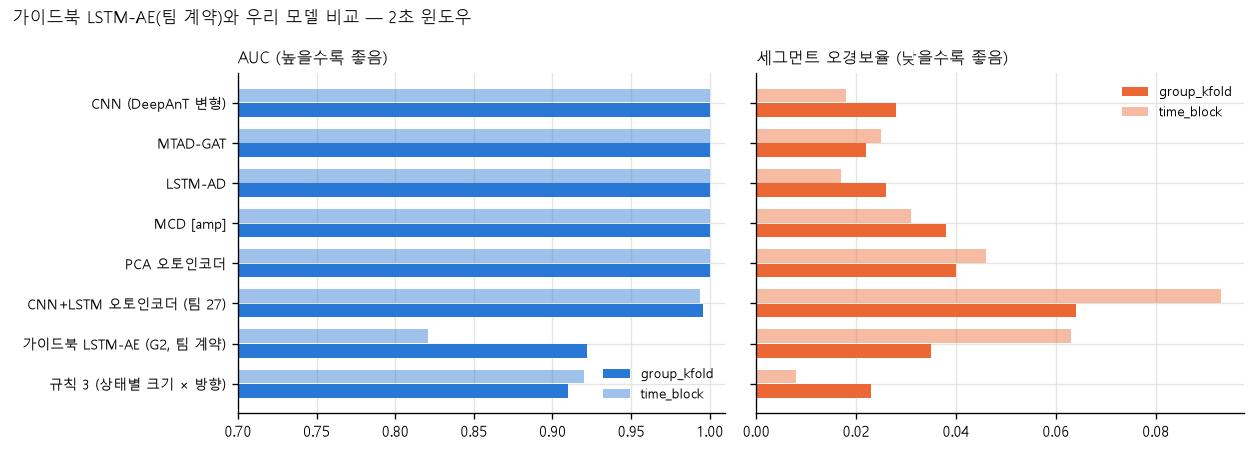

In [7]:
B._style()
d = cmp2.copy()
order = ["규칙 3 (상태별 크기 × 방향)", "가이드북 LSTM-AE (G2, 팀 계약)", "CNN+LSTM 오토인코더 (팀 27)", "PCA 오토인코더", "MCD [amp]", "LSTM-AD", "MTAD-GAT", "CNN (DeepAnT 변형)"]
d = d.loc[order]
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)
y = np.arange(len(d))
for ax, key, ttl, col in [(axes[0], "auc", "AUC (높을수록 좋음)", "#2a78d6"), (axes[1], "fpr_segment", "세그먼트 오경보율 (낮을수록 좋음)", "#eb6834")]:
    ax.barh(y - 0.18, d[(key, "group_kfold_seg")], 0.34, color=col, label="group_kfold")
    ax.barh(y + 0.18, d[(key, "time_block")], 0.34, color=col, alpha=0.45, label="time_block")
    ax.set_title(ttl, loc="left", fontsize=9.5)
    ax.legend(frameon=False, fontsize=8)
axes[0].set_yticks(y, d.index, fontsize=8.5)
axes[0].set_xlim(0.7, 1.01)
fig.suptitle("가이드북 LSTM-AE(팀 계약)와 우리 모델 비교 — 2초 윈도우", x=0.01, ha="left", fontsize=10)
fig.tight_layout(); fig.savefig(FIG / "g2_vs_models.png", dpi=120); plt.close(fig)
display(Image(FIG / "g2_vs_models.png"))

**발견 [데이터]** 가이드북 방식은 우리 예측 계열·MCD보다 AUC가 낮고(0.92 / 0.82 vs 1.00) 오경보는 비슷하거나 높으며(3.5% / 6.3%), 실제 이상 세그먼트를 일부 놓친다. 규칙 3(AUC 0.91 / 0.92)과는 group_kfold에서 비슷하고 time_block에서는 더 낮다. 복원 계열(팀 27 CNN+LSTM AE, PCA AE)과도 같은 방향이다.

## 4. 해석: 왜 이런 차이가 났나

| 후보 원인 | 근거 | 확인 여부 |
|---|---|---|
| 누수(형식·날짜)가 G1 수치를 부풀렸다 | G1 입력은 원시값 `abs()`, 평가 이상 = 다른 날, 임계를 이상으로 정함. G2에서 이를 제거하자 AUC 0.957 → 0.82~0.92 | 방향만 [추정] |
| G2의 학습 축소(800 → 100 epoch) | 2초 group_kfold의 epoch이 전부 100에 닿음(수렴 미확인) | **미분리** |
| 점수 정의 차이 | G1은 시퀀스 마지막 시점 오차, G2는 윈도우 안 시점 오차 평균 | **미분리** |
| 학습량 | time_block 1·2는 학습 정상 98·183 세그먼트 | 관찰 |

세 요인을 따로 떼려면 "팀 계약 + 800 epoch"(G1.5) 같은 실험이 필요하다. 이 데이터에서 가이드북 방식이 팀 모델보다 나쁜 이유를 하나로 단정할 수 없다. 다만 **입력·분할·임계를 팀 계약으로 맞추면 성능이 내려간다**는 점, 그리고 **그 상태에서도 우리 예측 계열·MCD는 13/13을 잡는다**는 점은 확인했다.

## 5. 정리

발견 → 시사점 → 활용은 `reports/29_model_guidebook_lstm_ae_JIW.md`에 정리했다.